# Energy analysis

In [2]:
!pip install tqdm

Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple


In [3]:
import calendar
import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

con = 'sqlite:////config/home-assistant_v2.db'

# Solar energy

In [4]:
_sql = """SELECT DATETIME("start_ts", "auto") AS datetime, sum FROM statistics 
JOIN statistics_meta ON statistics.metadata_id = statistics_meta.id 
WHERE statistic_id = "sensor.zonnepanelen_energie_geleverd" """
energy_solar = pd.read_sql(_sql, con, index_col="datetime", parse_dates="datetime").tz_localize("UTC")["sum"]
energy_solar

datetime
2021-01-01 00:00:00+00:00       37.7
2021-01-06 09:00:00+00:00       40.3
2021-01-06 10:00:00+00:00       40.4
2021-01-06 11:00:00+00:00       40.6
2021-01-06 12:00:00+00:00       40.7
                              ...   
2025-12-30 07:00:00+00:00    12644.8
2025-12-30 08:00:00+00:00    12644.8
2025-12-30 09:00:00+00:00    12644.8
2025-12-30 10:00:00+00:00    12644.8
2025-12-30 11:00:00+00:00    12644.8
Name: sum, Length: 21253, dtype: float64

## Cumulative

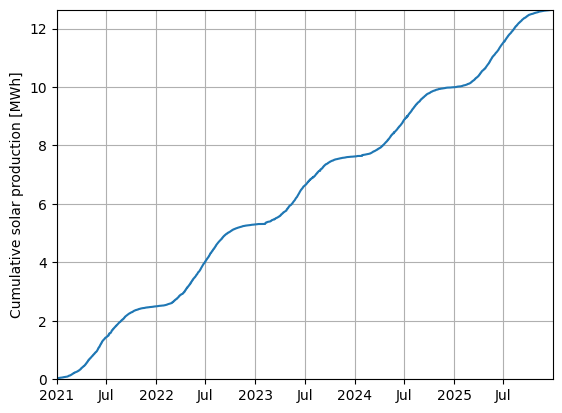

In [5]:
fig, ax = plt.subplots()
ax.plot(energy_solar / 1000)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Cumulative solar production [MWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

## Per month

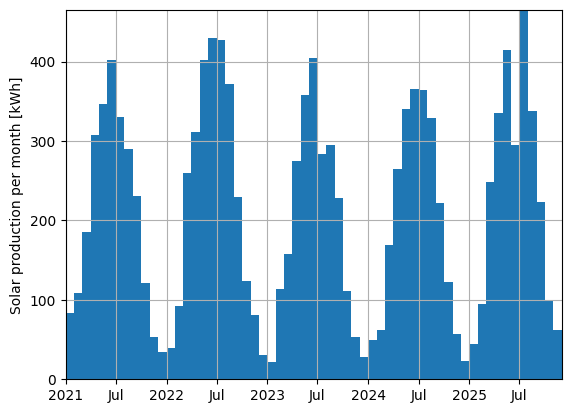

In [6]:
_data = energy_solar.groupby(pd.Grouper(freq='ME')).max()
_data["2020-12-31"] = 0
_data = _data.sort_index().diff().dropna().iloc[:-1]
fig, ax = plt.subplots()
ax.bar(
    x=_data.index - pd.offsets.MonthBegin(1),
    height=_data.values,
    width=_data.index.diff().fillna(pd.Timedelta("31days")),
    align="edge"
)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Solar production per month [kWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

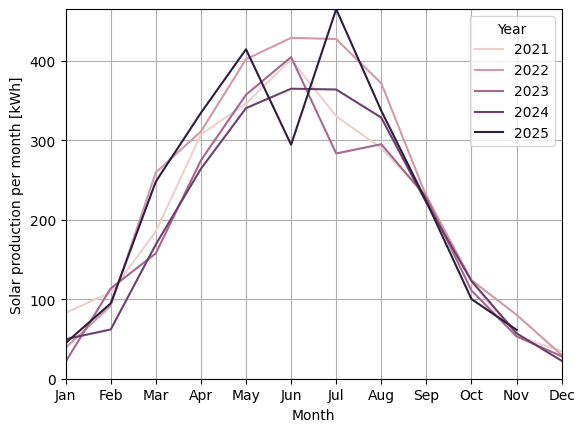

In [7]:
__data = pd.DataFrame(_data).assign(Month=lambda x: x.index.month, Year=lambda x: x.index.year)
fig, ax = plt.subplots()
sns.lineplot(__data, x="Month", y="sum", hue="Year", ax=ax)
ax.margins(0)
ax.set_xticks(range(13), calendar.month_abbr)
ax.set_xlim(1, None)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Solar production per month [kWh]");

## Cumulative per year

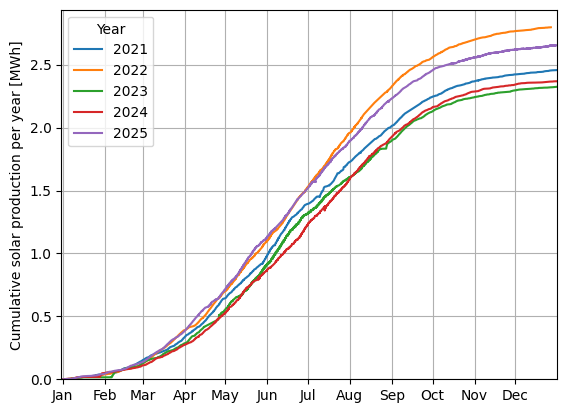

In [8]:
fig, ax = plt.subplots()
for group_label, group_df in energy_solar.groupby(lambda x: x.year):
    _data = (group_df - group_df.iloc[0])
    _data.index = _data.index.dayofyear + _data.index.hour / 12 + _data.index.minute / (12*60)
    ax.plot(_data / 1000, label=group_label)
ax.legend(title="Year")
ax.grid()
ax.set_xlim(0, 366)
ax.set_xticks(pd.date_range("2023-01-01", end="2023-12-31", freq="MS").dayofyear, calendar.month_abbr[1:])
ax.set_ylabel("Cumulative solar production per year [MWh]")
ax.set_ylim(0, None);

## Average per hour

(0.0, 0.8766389200292967)

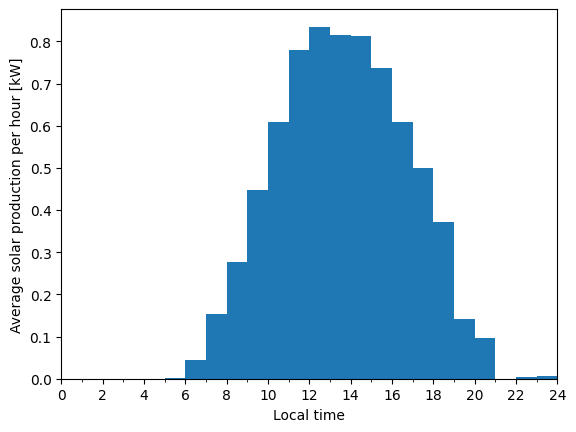

In [9]:
fig, ax = plt.subplots()
ax.bar(
    x=np.arange(0, 24),
    height=energy_solar.tz_convert("Europe/Amsterdam").diff().loc[lambda x: x<2].groupby(lambda x: x.hour).mean().values,
    width=1,
    align="edge"
)
ax.set_xlim(0, 24)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator())
ax.set_xlabel("Local time")
ax.set_ylabel("Average solar production per hour [kW]")
ax.set_ylim(0, None)

# Energy from grid

In [10]:
_sql = _sql = """SELECT DATETIME("start_ts", "auto") AS datetime, sum FROM statistics 
JOIN statistics_meta ON statistics.metadata_id = statistics_meta.id 
WHERE statistic_id = "sensor.netstroom_energiemeter_energie" """
energy_from_grid = pd.read_sql(_sql, con, index_col=['datetime'], parse_dates=["datetime"]).sort_index()["sum"].tz_localize("UTC")
energy_from_grid

datetime
2019-05-07 00:00:00+00:00        0.000000
2019-05-07 01:00:00+00:00        0.289703
2019-05-07 02:00:00+00:00        0.579407
2019-05-07 03:00:00+00:00        0.869110
2019-05-07 04:00:00+00:00        1.158813
                                 ...     
2026-01-04 03:00:00+00:00    18106.477500
2026-01-04 04:00:00+00:00    18106.477500
2026-01-04 05:00:00+00:00    18106.477500
2026-01-04 06:00:00+00:00    18106.477500
2026-01-04 07:00:00+00:00    18106.477500
Name: sum, Length: 56991, dtype: float64

## Cumulative

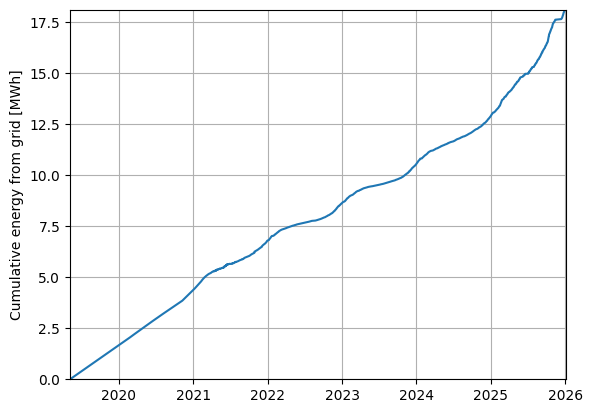

In [11]:
fig, ax = plt.subplots()
ax.plot(energy_from_grid / 1000)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Cumulative energy from grid [MWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

## Per month

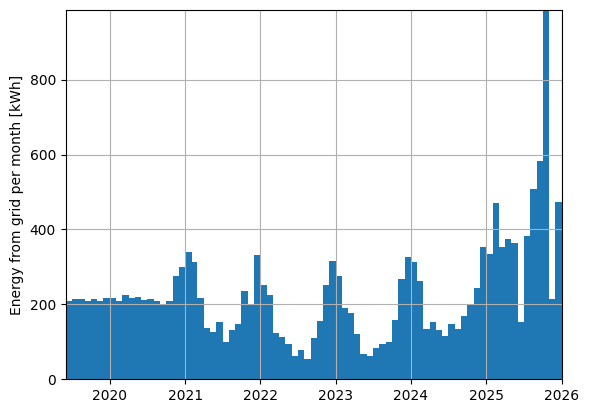

In [12]:
_data = energy_from_grid.groupby(pd.Grouper(freq='ME')).max()
_data = _data.sort_index().diff().dropna().iloc[:-1]
fig, ax = plt.subplots()
ax.bar(
    _data.index - pd.offsets.MonthBegin(1),
    _data.values,
    _data.index.diff().fillna(pd.Timedelta("31days")),
    align="edge"
)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Energy from grid per month [kWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

Text(0, 0.5, 'Energy from grid per month [kWh]')

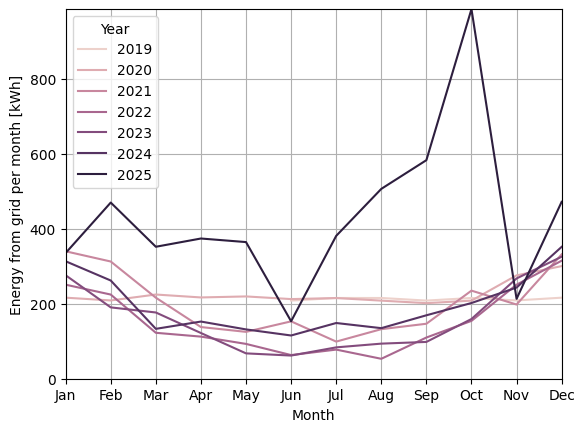

In [13]:
__data = pd.DataFrame(_data).assign(Month=lambda x: x.index.month, Year=lambda x: x.index.year)
fig, ax = plt.subplots()
sns.lineplot(__data, x="Month", y="sum", hue="Year", ax=ax)
ax.margins(0)
ax.set_xticks(range(13), calendar.month_abbr)
ax.set_xlim(1, None)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Energy from grid per month [kWh]")

## Cumulative per year

(0.0, 5.453411011647686)

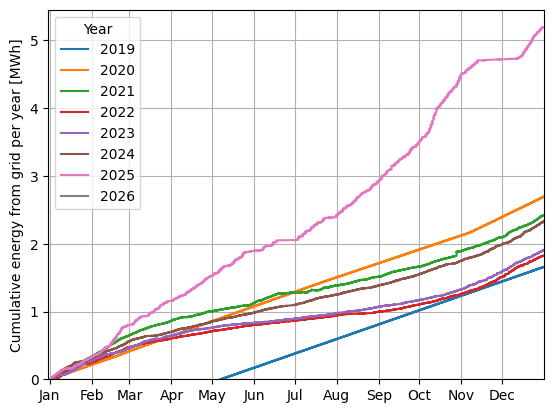

In [14]:
fig, ax = plt.subplots()
for group_label, group_df in energy_from_grid.groupby(lambda x: x.year):
    _data = (group_df - group_df.iloc[0])
    _data.index = _data.index.dayofyear + _data.index.hour / 12 + _data.index.minute / (12*60)
    ax.plot(_data / 1000, label=group_label)
ax.legend(title="Year")
ax.grid()
ax.set_xlim(0, 366)
ax.set_xticks(pd.date_range("2023-01-01", end="2023-12-31", freq="MS").dayofyear, calendar.month_abbr[1:])
ax.set_ylabel("Cumulative energy from grid per year [MWh]")
ax.set_ylim(0, None)

## Average per hour

(0.0, 0.33110974006160676)

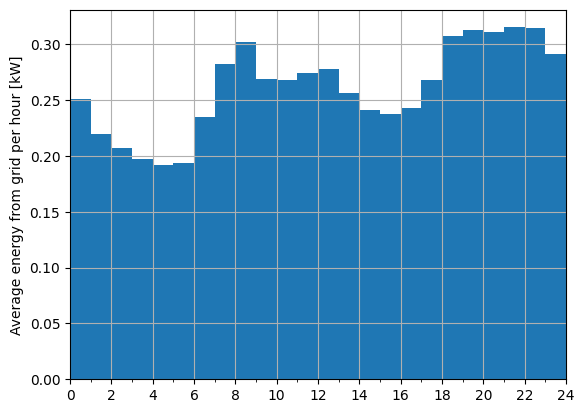

In [15]:
fig, ax = plt.subplots()
ax.bar(
    x=np.arange(0, 24),
    height=energy_from_grid.tz_convert("Europe/Amsterdam").diff().loc[lambda x: x<2].groupby(lambda x: x.hour).mean().values,
    width=1,
    align="edge"
)
ax.grid()
ax.set_xlim(0, 24)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator())
ax.set_ylabel("Average energy from grid per hour [kW]")
ax.set_ylim(0, None)

(0.0, 0.3936386699321038)

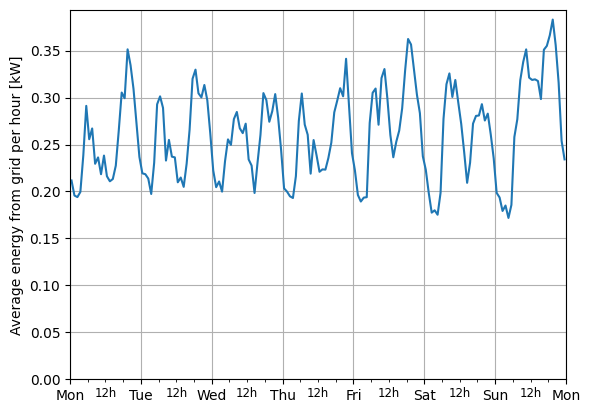

In [16]:
fig, ax = plt.subplots()
ax.plot(np.arange(1/48, 7+1/48, 1/24), energy_from_grid.diff().loc[lambda x: x<2].groupby(lambda x: x.dayofweek + x.hour/24).mean())
ax.grid()
ax.set_xlim(0, 7)
ax.set_xticks(range(8), list(calendar.day_abbr) + ["Mon"])
ax.set_xticks(np.arange(.5, 7), ["12h"]*7, minor=True, size="small")
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1/4))
ax.set_ylabel("Average energy from grid per hour [kW]")
ax.set_ylim(0, None)

# Grid to energy

In [17]:
_sql = _sql = """SELECT DATETIME("start_ts", "auto") AS datetime, sum FROM statistics 
JOIN statistics_meta ON statistics.metadata_id = statistics_meta.id 
WHERE statistic_id = "sensor.netstroom_energiemeter_teruggeleverde_energie" """
energy_to_grid = pd.read_sql(_sql, con, index_col=['datetime'], parse_dates=["datetime"]).sort_index()["sum"].tz_localize("UTC")
energy_to_grid

datetime
2021-01-01 00:00:00+00:00       0.404018
2021-01-01 01:00:00+00:00       0.007054
2021-01-01 02:00:00+00:00       0.014109
2021-01-01 03:00:00+00:00       0.021163
2021-01-01 04:00:00+00:00       0.028217
                                ...     
2026-01-04 03:00:00+00:00    9392.467141
2026-01-04 04:00:00+00:00    9392.467141
2026-01-04 05:00:00+00:00    9392.467141
2026-01-04 06:00:00+00:00    9392.467141
2026-01-04 07:00:00+00:00    9392.467141
Name: sum, Length: 40969, dtype: float64

## Cumulative

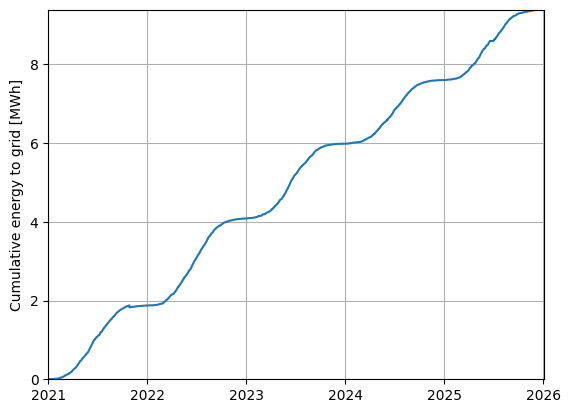

In [18]:
fig, ax = plt.subplots()
ax.plot(energy_to_grid / 1000)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Cumulative energy to grid [MWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

## Per month

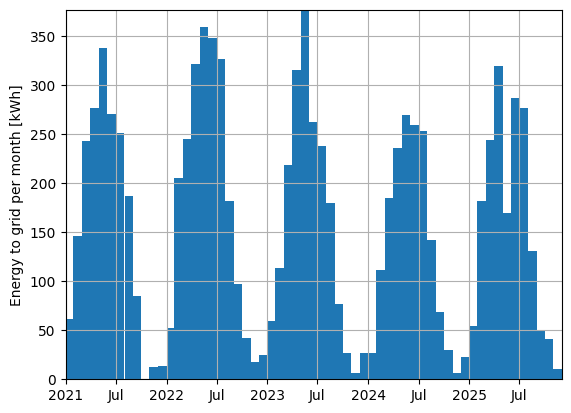

In [19]:
_data = energy_to_grid.groupby(pd.Grouper(freq='ME')).max()
_data = _data.sort_index().diff().dropna().iloc[:-1]
fig, ax = plt.subplots()
ax.bar(
    _data.index - pd.offsets.MonthBegin(1),
    _data.values,
    -_data.index.diff().fillna(pd.Timedelta("31days")),
    align="edge"
)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Energy to grid per month [kWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

Text(0, 0.5, 'Energy to grid per month [kWh]')

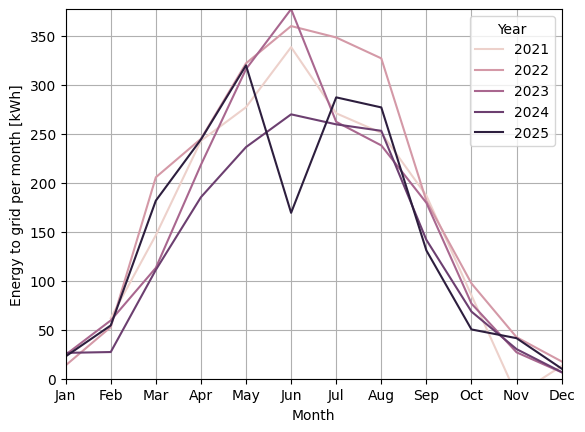

In [20]:
__data = pd.DataFrame(_data).assign(Month=lambda x: x.index.month, Year=lambda x: x.index.year)
fig, ax = plt.subplots()
sns.lineplot(__data, x="Month", y="sum", hue="Year", ax=ax)
ax.margins(0)
ax.set_xticks(range(13), calendar.month_abbr)
ax.set_xlim(1, None)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Energy to grid per month [kWh]")

## Cumulative per year

(0.0, 2.323995348179679)

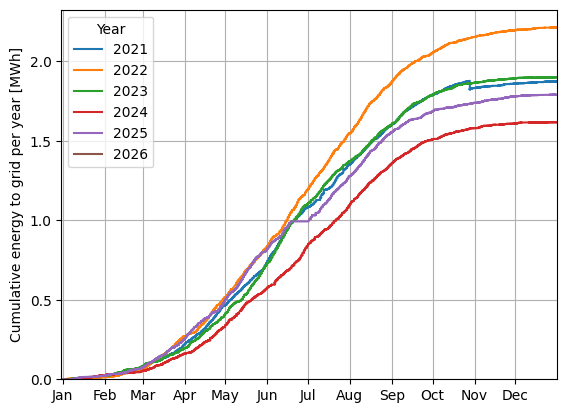

In [21]:
fig, ax = plt.subplots()
for group_label, group_df in energy_to_grid.groupby(lambda x: x.year):
    _data = (group_df - group_df.iloc[0])
    _data.index = _data.index.dayofyear + _data.index.hour / 12 + _data.index.minute / (12*60)
    ax.plot(_data / 1000, label=group_label)
ax.legend(title="Year")
ax.grid()
ax.set_xlim(0, 366)
ax.set_xticks(pd.date_range("2023-01-01", end="2023-12-31", freq="MS").dayofyear, calendar.month_abbr[1:])
ax.set_ylabel("Cumulative energy to grid per year [MWh]")
ax.set_ylim(0, None)

## Average per hour

(0.0, 0.7075766783037306)

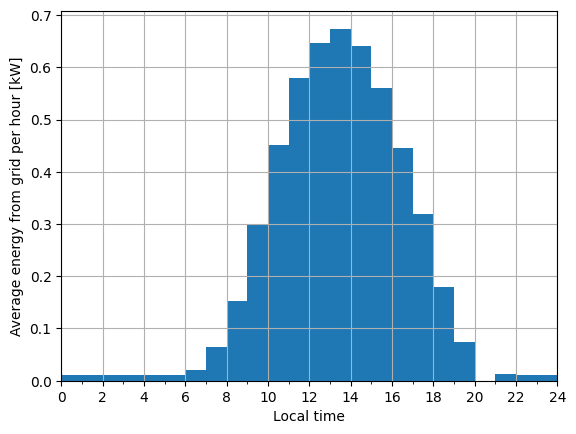

In [22]:
fig, ax = plt.subplots()
ax.bar(
    x=np.arange(0, 24),
    height=energy_to_grid.tz_convert("Europe/Amsterdam").diff().loc[lambda x: x<2].groupby(lambda x: x.hour).mean().values,
    width=1,
    align="edge"
)
ax.grid()
ax.set_xlim(0, 24)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator())
ax.set_xlabel("Local time")
ax.set_ylabel("Average energy from grid per hour [kW]")
ax.set_ylim(0, None)

# Netto grid transport

In [23]:
energy_out = energy_to_grid.reindex(pd.date_range("2019-05-07 00:00", pd.Timestamp.now().floor("h"), freq="h", tz="UTC")).ffill().fillna(0)
energy_in = energy_from_grid.reindex(pd.date_range("2019-05-07 00:00", pd.Timestamp.now().floor("h"), freq="h", tz="UTC")).ffill().fillna(0)
energy_netto = energy_in - energy_out
energy_netto

2019-05-07 00:00:00+00:00       0.000000
2019-05-07 01:00:00+00:00       0.289703
2019-05-07 02:00:00+00:00       0.579407
2019-05-07 03:00:00+00:00       0.869110
2019-05-07 04:00:00+00:00       1.158813
                                ...     
2026-01-04 05:00:00+00:00    8714.010359
2026-01-04 06:00:00+00:00    8714.010359
2026-01-04 07:00:00+00:00    8714.010359
2026-01-04 08:00:00+00:00    8714.010359
2026-01-04 09:00:00+00:00    8714.010359
Freq: h, Name: sum, Length: 58426, dtype: float64

## Cumulative

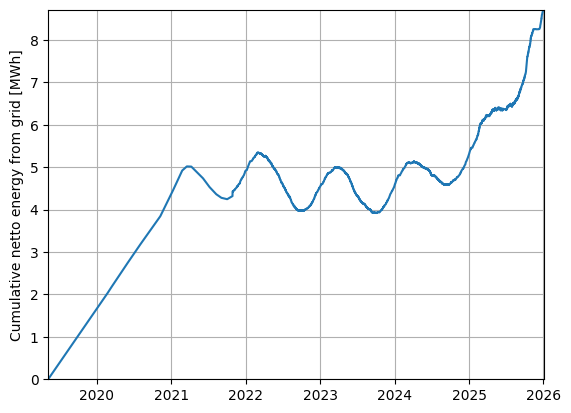

In [24]:
fig, ax = plt.subplots()
ax.plot(energy_netto / 1000)
ax.margins(0)
ax.set_ylim(0, None)
ax.grid()
ax.set_ylabel("Cumulative netto energy from grid [MWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

## Per month

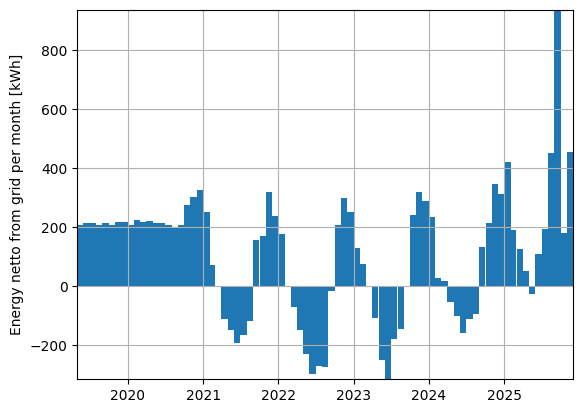

In [25]:
_data = energy_netto.groupby(pd.Grouper(freq='ME')).max()
_data = _data.sort_index().diff().dropna().iloc[:-1]
fig, ax = plt.subplots()
ax.bar(
    _data.index - pd.offsets.MonthBegin(1),
    _data.values,
    -_data.index.diff().fillna(pd.Timedelta("31days")),
    align="edge"
)
ax.margins(0)
ax.grid()
ax.set_ylabel("Energy netto from grid per month [kWh]")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

Text(0, 0.5, 'Energy netto from grid per month [kWh]')

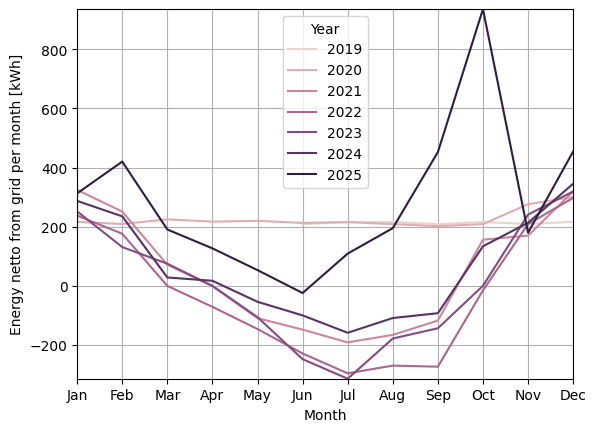

In [26]:
__data = pd.DataFrame(_data).assign(Month=lambda x: x.index.month, Year=lambda x: x.index.year)
fig, ax = plt.subplots()
sns.lineplot(__data, x="Month", y="sum", hue="Year", ax=ax)
ax.margins(0)
ax.set_xticks(range(13), calendar.month_abbr)
ax.set_xlim(1, None)
ax.grid()
ax.set_ylabel("Energy netto from grid per month [kWh]")

## Cumulative per year

Text(0, 0.5, 'Cumulative energy netto from grid per year [MWh]')

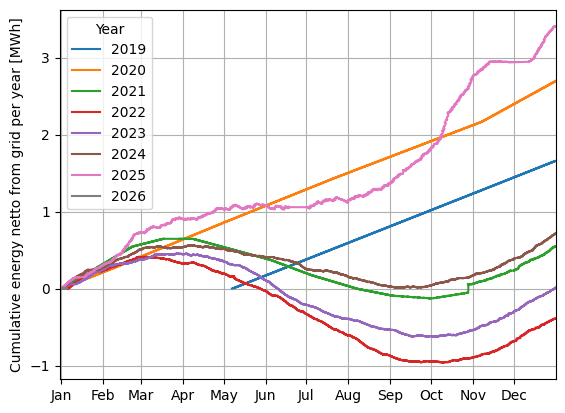

In [27]:
fig, ax = plt.subplots()
for group_label, group_df in energy_netto.groupby(lambda x: x.year):
    _data = (group_df - group_df.iloc[0])
    _data.index = _data.index.dayofyear + _data.index.hour / 12 + _data.index.minute / (12*60)
    ax.plot(_data / 1000, label=group_label)
ax.legend(title="Year")
ax.grid()
ax.set_xlim(0, 366)
ax.set_xticks(pd.date_range("2023-01-01", end="2023-12-31", freq="MS").dayofyear, calendar.month_abbr[1:])
ax.set_ylabel("Cumulative energy netto from grid per year [MWh]")

## Average per hour

Text(0, 0.5, 'Average energy netto from grid per hour [kW]')

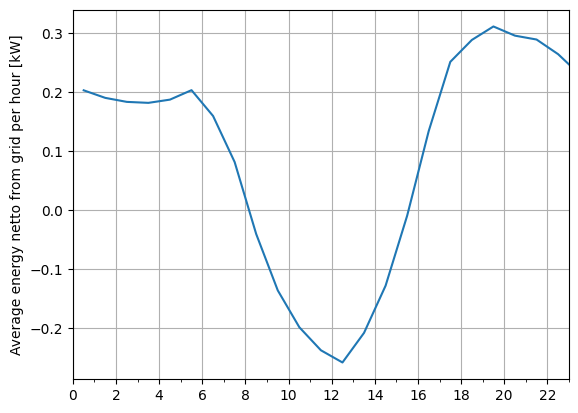

In [28]:
fig, ax = plt.subplots()
ax.plot(np.arange(.5, 24), energy_netto.diff().loc[lambda x: x<2].groupby(lambda x: x.hour).mean())
ax.grid()
ax.set_xlim(0, 23)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator())
ax.set_ylabel("Average energy netto from grid per hour [kW]")

Text(0, 0.5, 'Average energy from grid per hour [kW]')

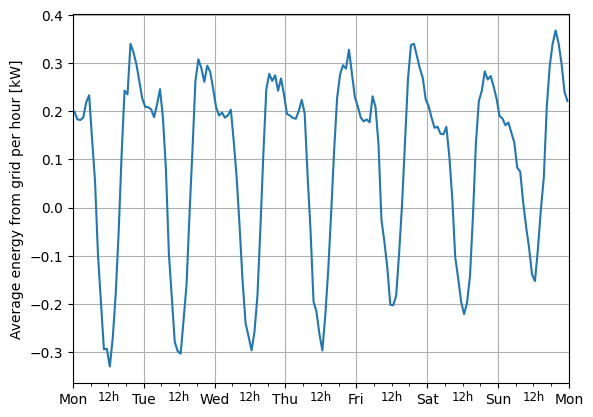

In [29]:
fig, ax = plt.subplots()
ax.plot(np.arange(1/48, 7+1/48, 1/24), energy_netto.diff().loc[lambda x: x<2].groupby(lambda x: x.dayofweek + x.hour/24).mean())
ax.grid()
ax.set_xlim(0, 7)
ax.set_xticks(range(8), list(calendar.day_abbr) + ["Mon"])
ax.set_xticks(np.arange(.5, 7), ["12h"]*7, minor=True, size="small")
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1/4))
ax.set_ylabel("Average energy from grid per hour [kW]")

# Overview energy transport

In [30]:
data = pd.DataFrame(dict(energy_from_grid=energy_from_grid, energy_to_grid=energy_to_grid, energy_solar=energy_solar)).resample("h").max().ffill().fillna(0)
data

,energy_from_grid,energy_to_grid,energy_solar
datetime,,,
2019-05-07 00:00:00+00:00,0.000000,0.000000,0.0
2019-05-07 01:00:00+00:00,0.289703,0.000000,0.0
2019-05-07 02:00:00+00:00,0.579407,0.000000,0.0
2019-05-07 03:00:00+00:00,0.869110,0.000000,0.0
2019-05-07 04:00:00+00:00,1.158813,0.000000,0.0
...,...,...,...
2026-01-04 03:00:00+00:00,18106.477500,9392.467141,12644.8
2026-01-04 04:00:00+00:00,18106.477500,9392.467141,12644.8
2026-01-04 05:00:00+00:00,18106.477500,9392.467141,12644.8


## Per year

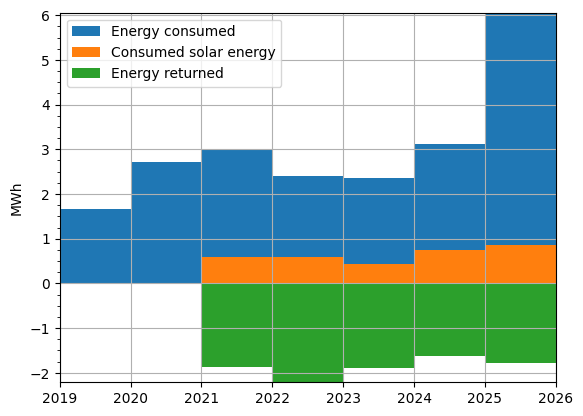

In [31]:
_x = data.resample("YE").agg(np.ptp) / 1000
_x.index = _x.index.year
fig, ax = plt.subplots()
ax.fill_between(_x.index, _x["energy_from_grid"] + _x["energy_solar"] - _x["energy_to_grid"], step="post", label="Energy consumed")
ax.fill_between(_x.index, _x["energy_solar"] - _x["energy_to_grid"], step="post", label="Consumed solar energy")
ax.fill_between(_x.index, -_x["energy_to_grid"], step="post", label="Energy returned")
ax.margins(0)
ax.set_ylabel("MWh")
ax.grid()
ax.yaxis.set_minor_locator(mticker.MultipleLocator(.25))
ax.legend()

## Per month

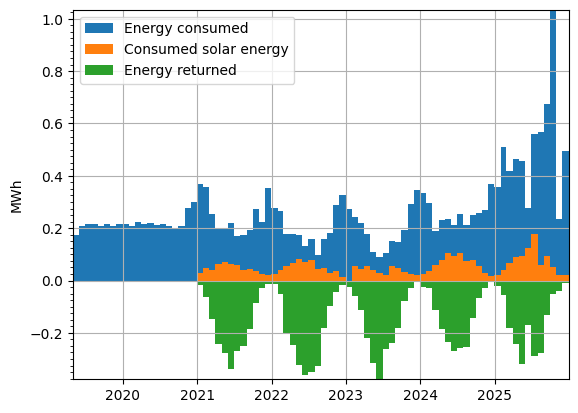

In [32]:
_x = data.resample("ME", label="left").agg(np.ptp) / 1000
fig, ax = plt.subplots()
ax.fill_between(_x.index, _x["energy_from_grid"] + _x["energy_solar"] - _x["energy_to_grid"], step="post", label="Energy consumed")
ax.fill_between(_x.index, _x["energy_solar"] - _x["energy_to_grid"], step="post", label="Consumed solar energy")
ax.fill_between(_x.index, -_x["energy_to_grid"], step="post", label="Energy returned")
ax.margins(0)
ax.set_ylabel("MWh")
ax.yaxis.set_minor_locator(mticker.MultipleLocator(.025))
ax.grid()
ax.legend()

# Self consumed solar energy
## Per month

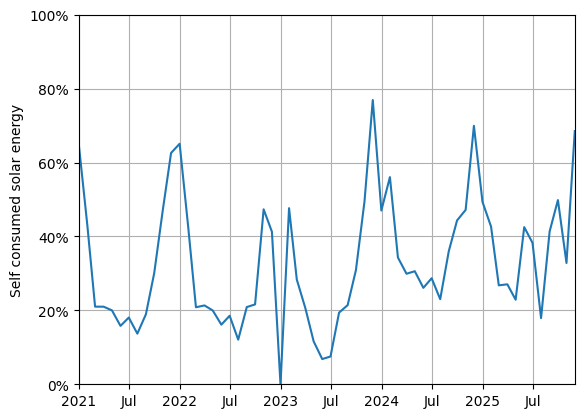

In [33]:
__x = ((_x["energy_solar"] - _x["energy_to_grid"]) / _x["energy_solar"]).dropna().clip(lower=0).rename("self")
fig, ax = plt.subplots()
ax.plot(__x)
ax.margins(0)
ax.set_ylim(0, 1)
ax.set_ylabel("Self consumed solar energy")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.grid()

## Per year

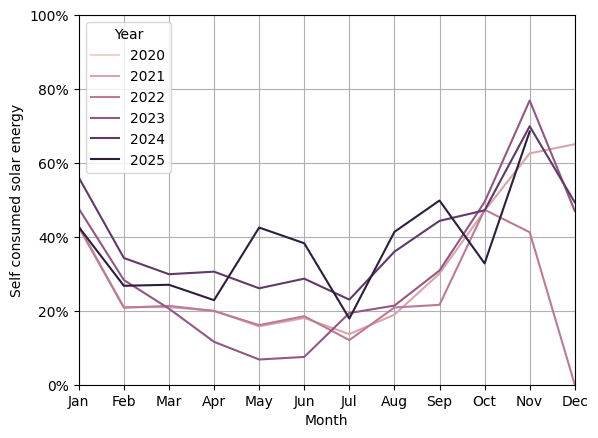

In [34]:
__data = pd.DataFrame(__x).assign(Month=lambda x: x.index.month, Year=lambda x: x.index.year)
fig, ax = plt.subplots()
sns.lineplot(__data, x="Month", y="self", hue="Year", ax=ax)
ax.margins(0)
ax.set_xticks(range(13), calendar.month_abbr)
ax.set_xlim(1, None)
ax.set_ylim(0, 1)
ax.set_ylabel("Self consumed solar energy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.grid()

# Self-sufficiency

In [35]:
_data = ((data["energy_solar"].diff() - data["energy_to_grid"].diff()) / (data["energy_solar"].diff() - data["energy_to_grid"].diff() + data["energy_from_grid"].diff())).dropna().rename("self")

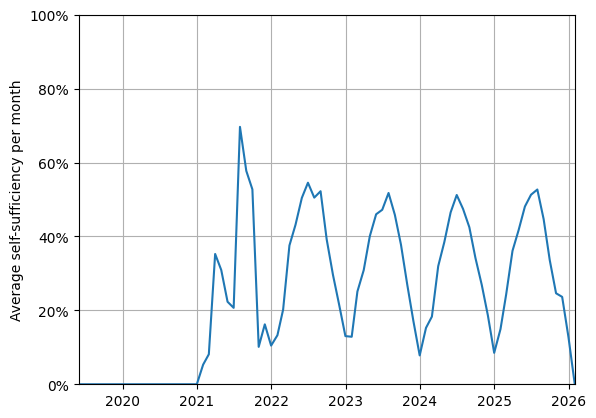

In [36]:
fig, ax = plt.subplots()
ax.plot(_data.clip(lower=0, upper=1).resample("ME").mean())
ax.margins(0)
ax.set_ylim(0, 1)
ax.set_ylabel("Average self-sufficiency per month")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.grid()
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

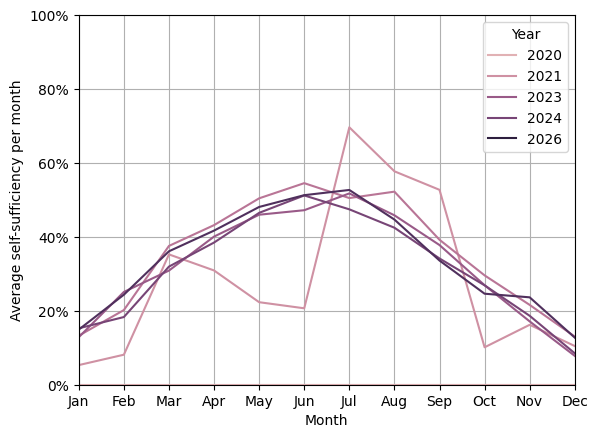

In [37]:
__data = pd.DataFrame(_data.clip(lower=0, upper=1).resample("ME").mean()).assign(Month=lambda x: x.index.month, Year=lambda x: x.index.year)
fig, ax = plt.subplots()
sns.lineplot(__data, x="Month", y="self", hue="Year", ax=ax)
ax.margins(0)
ax.set_xticks(range(13), calendar.month_abbr)
ax.set_xlim(1, None)
ax.set_ylim(0, 1)
ax.set_ylabel("Average self-sufficiency per month")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.grid()